In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models.densenet import DenseNet121_Weights
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Data transforms (DenseNet-121 uses 224x224 input)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (update path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split train/val (80/20)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform
val_dataset.dataset.transform = val_transform

# Loaders (batch 32; fits 6GB VRAM, ~3-4GB usage)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Classes
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train: 2349, Val: 262


In [4]:
# Load DenseNet-121
model = models.densenet121(weights=DenseNet121_Weights.DEFAULT)

# Freeze except classifier
for param in model.parameters():
    param.requires_grad = False

# Modify classifier
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 5)

# To GPU
model = model.to(device)

# Summary (optional)
print(model)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/rifat-cou/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████████████████████████████████| 30.8M/30.8M [00:20<00:00, 1.59MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Classifier only first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/200 - Train Loss: 0.1781, Acc: 0.9455 | Val Loss: 0.3226, Acc: 0.8893
Epoch 2/200 - Train Loss: 0.1787, Acc: 0.9434 | Val Loss: 0.3245, Acc: 0.8969
Epoch 3/200 - Train Loss: 0.1898, Acc: 0.9391 | Val Loss: 0.3176, Acc: 0.9008
Epoch 4/200 - Train Loss: 0.1771, Acc: 0.9430 | Val Loss: 0.3265, Acc: 0.8931
Epoch 5/200 - Train Loss: 0.1790, Acc: 0.9421 | Val Loss: 0.3224, Acc: 0.8855
Epoch 6/200 - Train Loss: 0.1773, Acc: 0.9417 | Val Loss: 0.3196, Acc: 0.8893
Epoch 7/200 - Train Loss: 0.1871, Acc: 0.9430 | Val Loss: 0.3158, Acc: 0.8969
Epoch 8/200 - Train Loss: 0.1783, Acc: 0.9447 | Val Loss: 0.3148, Acc: 0.8931
Epoch 9/200 - Train Loss: 0.1877, Acc: 0.9361 | Val Loss: 0.3316, Acc: 0.8740
Epoch 10/200 - Train Loss: 0.1763, Acc: 0.9476 | Val Loss: 0.3082, Acc: 0.8855
Epoch 11/200 - Train Loss: 0.1677, Acc: 0.9481 | Val Loss: 0.3050, Acc: 0.9008
Epoch 12/200 - Train Loss: 0.1818, Acc: 0.9459 | Val Loss: 0.3159, Acc: 0.8893
Epoch 13/200 - Train Loss: 0.1737, Acc: 0.9434 | Val Loss: 0.

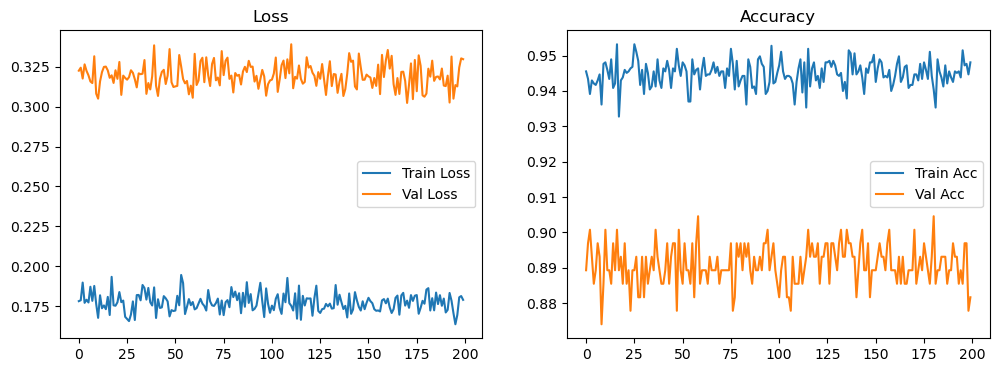

In [8]:
num_epochs = 200
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [9]:
# Eval
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
DenseNet = os.path.join(model_path, 'DenseNet_121')
os.makedirs(DenseNet, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(DenseNet, 'densenet121_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.77      0.80      0.79        55
      Cowpox       0.96      0.96      0.96        53
     Measles       0.97      0.95      0.96        41
   MonkeyPox       0.85      0.78      0.82        60
      Normal       0.88      0.94      0.91        53

    accuracy                           0.88       262
   macro avg       0.89      0.89      0.89       262
weighted avg       0.88      0.88      0.88       262

Accuracy: 0.8817
